# EDA4 — CycPeptMPDB-4D Permeability ML 분석

전처리된 `CycPeptMPDB-4D_with_assay_descriptors_preprocessed.csv` 에 대한 머신러닝 회귀 분석.

**모델**
1. Random Forest Regressor
2. XGBoost Regressor
3. Lasso (L1 정규화)
4. Ridge (L2 정규화)

**타겟**: `PAMPA-4D` (log Papp 값)

**평가**: 5-fold CV (R², RMSE, MAE) + held-out test set

**비교 항목**: 성능, 학습/예측 시간, 특성 중요도(또는 계수)

In [ ]:
import os
# GPU 7 고정 — xgboost(CUDA) import 전에 설정해야 적용됨.
# 이후 device="cuda" 는 물리 GPU 7 을 가리킴 (visible index 0).
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "../data/CycPeptMPDB-4D_with_assay_descriptors_preprocessed.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
print("Shape:", df.shape)
df.head(3)

## 1. 특성/타겟 준비

- 타겟: `PAMPA-4D`
- 메타/식별/타겟 누설(leakage) 가능 컬럼 제외
- `Molecule_Shape` 같은 범주형은 one-hot encoding
- 결측치는 median 으로 보간
- 분산 0 컬럼 제거

In [2]:
TARGET = "PAMPA-4D"

# 메타/식별 컬럼 (학습 제외) — Sequence_LogP/TPSA 는 list-string 형태라 함께 제외
META_COLS = [
    "CycPeptMPDB_ID", "Source", "Original_Name_in_Source_Literature",
    "Structurally_Unique_ID", "SMILES", "HELM", "Sequence",
    "Sequence_LogP", "Sequence_TPSA", "HELM_URL",
    "Year", "Version",
]

# 누설 가능 타겟 유사 컬럼
LEAKAGE_COLS = [
    "PAMPA", "Permeability", "Caco2", "MDCK", "RRCK",
    "Detection_Limit_1", "Detection_Limit_2",
    "R_PAMAP", "R_Caco2", "R_MDCK", "R_RRCK", "T_PAMPA",
]

drop_cols = [c for c in META_COLS + LEAKAGE_COLS if c in df.columns]
X_full = df.drop(columns=drop_cols + [TARGET])
y = df[TARGET].astype(float)

cat_cols = X_full.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()
print(f"수치형 특성: {len(num_cols)}개, 범주형 특성: {len(cat_cols)}개 -> {cat_cols}")

X = pd.get_dummies(X_full, columns=cat_cols, drop_first=True)

# inf → NaN, NaN → median 보간
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

# RDKit Ipc 등 거대값 클리핑 (float32 안전)
F32_MAX = np.finfo(np.float32).max / 10
X = X.clip(lower=-F32_MAX, upper=F32_MAX)

zero_var = X.columns[X.nunique() <= 1].tolist()
if zero_var:
    print(f"분산 0 컬럼 제거: {len(zero_var)}개")
    X = X.drop(columns=zero_var)

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

# XGBoost 호환: 컬럼명에 [, ], < 가 있으면 안 됨 → sanitize
import re
def _sanitize(c):
    return re.sub(r"[\[\]<>]", "_", str(c))
X.columns = [_sanitize(c) for c in X.columns]

X = X.astype(np.float64)
n_nan = int(np.isnan(X.values).sum())
n_inf = int(np.isinf(X.values).sum())
print(f"검사: NaN={n_nan}, Inf={n_inf}, max|X|={np.abs(X.values).max():.3e}")

print(f"\n최종 X shape: {X.shape}")
print(f"y shape: {y.shape}, y range: [{y.min():.3f}, {y.max():.3f}]")


수치형 특성: 223개, 범주형 특성: 1개 -> ['Molecule_Shape']
분산 0 컬럼 제거: 69개
검사: NaN=0, Inf=0, max|X|=3.403e+37

최종 X shape: (4925, 155)
y shape: (4925,), y range: [-9.460, -4.000]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=kf):
    t0 = time.time()
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="r2", n_jobs=-1)
    cv_rmse = -cross_val_score(model, X_tr, y_tr, cv=cv,
                                scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_mae = -cross_val_score(model, X_tr, y_tr, cv=cv,
                               scoring="neg_mean_absolute_error", n_jobs=-1)
    cv_time = time.time() - t0

    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - t0

    test_r2 = r2_score(y_te, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    test_mae = mean_absolute_error(y_te, y_pred)

    res = {
        "model": model,
        "y_pred": y_pred,
        "cv_r2_mean": cv_r2.mean(), "cv_r2_std": cv_r2.std(),
        "cv_rmse_mean": cv_rmse.mean(), "cv_rmse_std": cv_rmse.std(),
        "cv_mae_mean": cv_mae.mean(), "cv_mae_std": cv_mae.std(),
        "test_r2": test_r2, "test_rmse": test_rmse, "test_mae": test_mae,
        "fit_time": fit_time, "pred_time": pred_time, "cv_time": cv_time,
    }
    print(f"\n=== {name} ===")
    print(f"  CV  R²={res['cv_r2_mean']:.4f}±{res['cv_r2_std']:.4f}  "
          f"RMSE={res['cv_rmse_mean']:.4f}±{res['cv_rmse_std']:.4f}  "
          f"MAE={res['cv_mae_mean']:.4f}±{res['cv_mae_std']:.4f}")
    print(f"  Test R²={res['test_r2']:.4f}  RMSE={res['test_rmse']:.4f}  MAE={res['test_mae']:.4f}")
    print(f"  fit={fit_time:.2f}s  pred={pred_time:.4f}s")
    return res

Train: (3940, 155), Test: (985, 155)


## 2. Random Forest Regressor

In [4]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
results["RandomForest"] = evaluate_model("RandomForest", rf, X_train, y_train, X_test, y_test)


=== RandomForest ===
  CV  R²=0.5855±0.0209  RMSE=0.4394±0.0101  MAE=0.3293±0.0045
  Test R²=0.5436  RMSE=0.4536  MAE=0.3308
  fit=0.53s  pred=0.1704s


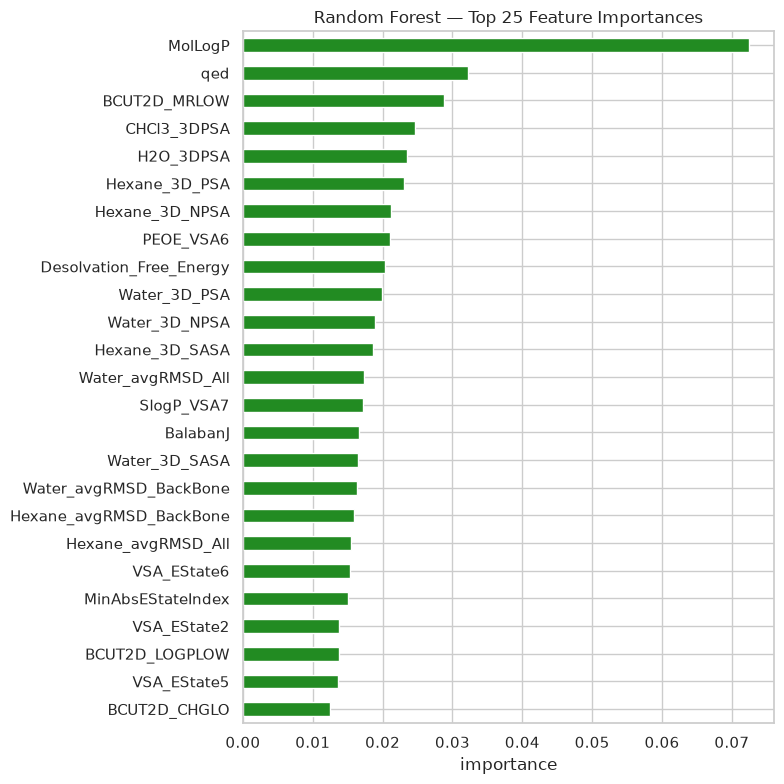

Top 10:
MolLogP                    0.072407
qed                        0.032218
BCUT2D_MRLOW               0.028827
CHCl3_3DPSA                0.024579
H2O_3DPSA                  0.023456
Hexane_3D_PSA              0.023026
Hexane_3D_NPSA             0.021190
PEOE_VSA6                  0.020995
Desolvation_Free_Energy    0.020335
Water_3D_PSA               0.019864
dtype: float64


In [5]:
rf_imp = pd.Series(results["RandomForest"]["model"].feature_importances_,
                   index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
rf_imp.head(25).iloc[::-1].plot.barh(ax=ax, color="forestgreen")
ax.set_title("Random Forest — Top 25 Feature Importances")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

print("Top 10:")
print(rf_imp.head(10))

## 3. XGBoost Regressor

In [6]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",  # GPU (CUDA_VISIBLE_DEVICES=7 → 물리 GPU 7)
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
results["XGBoost"] = evaluate_model("XGBoost", xgb_model, X_train, y_train, X_test, y_test)


=== XGBoost ===
  CV  R²=0.5797±0.0165  RMSE=0.4426±0.0113  MAE=0.3318±0.0057
  Test R²=0.5673  RMSE=0.4417  MAE=0.3242
  fit=2.44s  pred=0.0672s


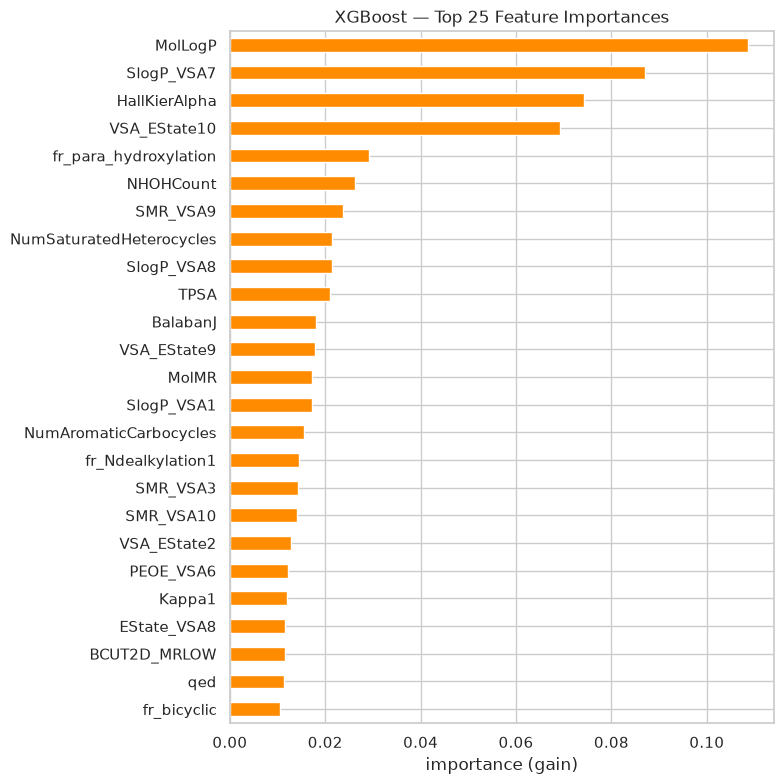

Top 10:
MolLogP                     0.108652
SlogP_VSA7                  0.087101
HallKierAlpha               0.074187
VSA_EState10                0.069233
fr_para_hydroxylation       0.029145
NHOHCount                   0.026230
SMR_VSA9                    0.023798
NumSaturatedHeterocycles    0.021445
SlogP_VSA8                  0.021409
TPSA                        0.020904
dtype: float32


In [7]:
xgb_imp = pd.Series(results["XGBoost"]["model"].feature_importances_,
                    index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
xgb_imp.head(25).iloc[::-1].plot.barh(ax=ax, color="darkorange")
ax.set_title("XGBoost — Top 25 Feature Importances")
ax.set_xlabel("importance (gain)")
plt.tight_layout()
plt.show()

print("Top 10:")
print(xgb_imp.head(10))

## 4. Lasso (L1 정규화)

L1 페널티로 계수의 일부를 0으로 만들어 자동 특성 선택. 표준화 필수.

In [8]:
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(alphas=np.logspace(-4, 1, 50), cv=5,
                       max_iter=20000, n_jobs=-1, random_state=RANDOM_STATE)),
])
results["Lasso"] = evaluate_model("Lasso", lasso_pipe, X_train, y_train, X_test, y_test)

best_alpha_l1 = results["Lasso"]["model"].named_steps["lasso"].alpha_
print(f"\nBest Lasso alpha: {best_alpha_l1:.5f}")


=== Lasso ===
  CV  R²=0.4437±0.0169  RMSE=0.5092±0.0113  MAE=0.3753±0.0052
  Test R²=0.3760  RMSE=0.5304  MAE=0.3706
  fit=3.17s  pred=0.0025s

Best Lasso alpha: 0.00010


Lasso 가 선택한 특성 수: 89 / 155


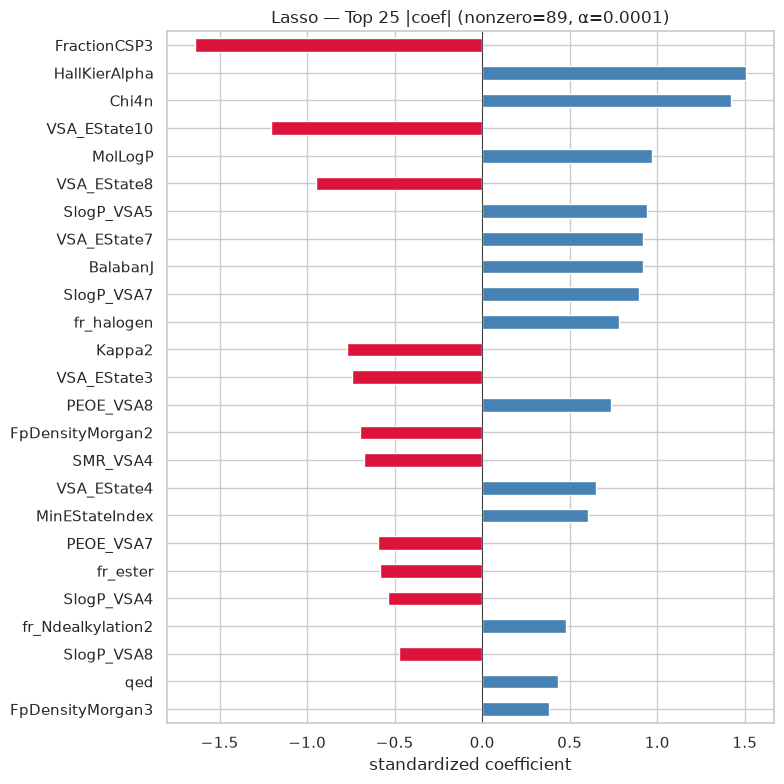

In [9]:
lasso_coef = pd.Series(
    results["Lasso"]["model"].named_steps["lasso"].coef_,
    index=X_train.columns,
)
n_nonzero = (lasso_coef != 0).sum()
print(f"Lasso 가 선택한 특성 수: {n_nonzero} / {len(lasso_coef)}")

top = lasso_coef[lasso_coef != 0].abs().sort_values(ascending=False).head(25).index
fig, ax = plt.subplots(figsize=(8, 8))
colors = ["steelblue" if v > 0 else "crimson" for v in lasso_coef.loc[top].iloc[::-1]]
lasso_coef.loc[top].iloc[::-1].plot.barh(ax=ax, color=colors)
ax.set_title(f"Lasso — Top 25 |coef| (nonzero={n_nonzero}, α={best_alpha_l1:.4f})")
ax.set_xlabel("standardized coefficient")
ax.axvline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

## 5. Ridge (L2 정규화)

L2 페널티로 계수를 축소. 다중공선성에 강건. 표준화 필수.

In [10]:
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)),
])
results["Ridge"] = evaluate_model("Ridge", ridge_pipe, X_train, y_train, X_test, y_test)

best_alpha_l2 = results["Ridge"]["model"].named_steps["ridge"].alpha_
print(f"\nBest Ridge alpha: {best_alpha_l2:.5f}")


=== Ridge ===
  CV  R²=0.4468±0.0158  RMSE=0.5078±0.0130  MAE=0.3747±0.0060
  Test R²=0.3747  RMSE=0.5310  MAE=0.3711
  fit=1.05s  pred=0.0016s

Best Ridge alpha: 0.86851


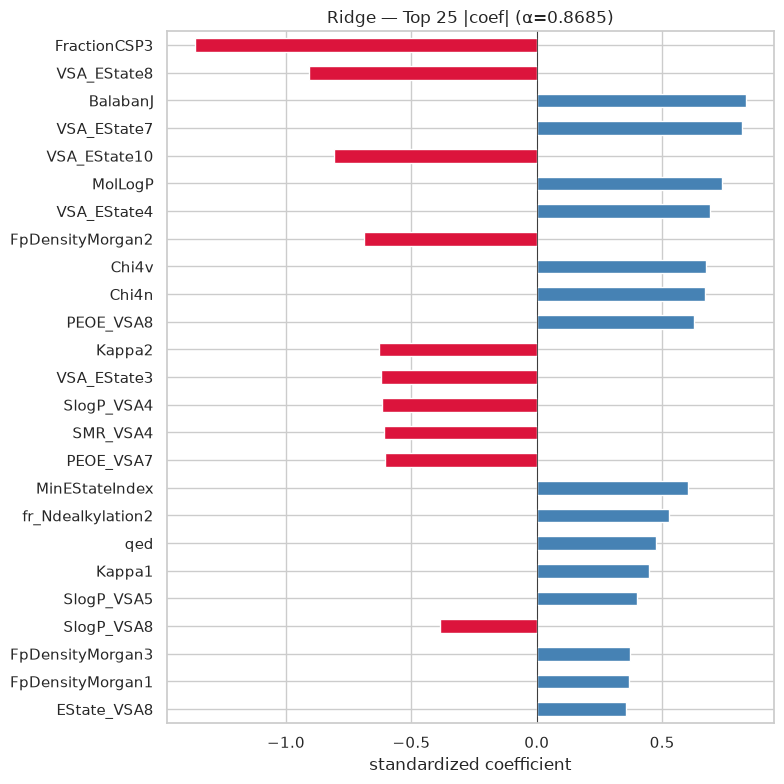

In [11]:
ridge_coef = pd.Series(
    results["Ridge"]["model"].named_steps["ridge"].coef_,
    index=X_train.columns,
)

top = ridge_coef.abs().sort_values(ascending=False).head(25).index
fig, ax = plt.subplots(figsize=(8, 8))
colors = ["steelblue" if v > 0 else "crimson" for v in ridge_coef.loc[top].iloc[::-1]]
ridge_coef.loc[top].iloc[::-1].plot.barh(ax=ax, color=colors)
ax.set_title(f"Ridge — Top 25 |coef| (α={best_alpha_l2:.4f})")
ax.set_xlabel("standardized coefficient")
ax.axvline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

## 6. 모델 비교

In [12]:
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        "model": name,
        "CV_R2": f"{r['cv_r2_mean']:.4f} ± {r['cv_r2_std']:.4f}",
        "CV_RMSE": f"{r['cv_rmse_mean']:.4f} ± {r['cv_rmse_std']:.4f}",
        "CV_MAE": f"{r['cv_mae_mean']:.4f} ± {r['cv_mae_std']:.4f}",
        "Test_R2": round(r["test_r2"], 4),
        "Test_RMSE": round(r["test_rmse"], 4),
        "Test_MAE": round(r["test_mae"], 4),
        "fit_s": round(r["fit_time"], 2),
        "pred_s": round(r["pred_time"], 4),
    })
summary = pd.DataFrame(summary_rows).set_index("model")
summary

,CV_R2,CV_RMSE,CV_MAE,Test_R2,Test_RMSE,Test_MAE,fit_s,pred_s
model,,,,,,,,
RandomForest,0.5855 ± 0.0209,0.4394 ± 0.0101,0.3293 ± 0.0045,0.5436,0.4536,0.3308,0.53,0.1704
XGBoost,0.5797 ± 0.0165,0.4426 ± 0.0113,0.3318 ± 0.0057,0.5673,0.4417,0.3242,2.44,0.0672
Lasso,0.4437 ± 0.0169,0.5092 ± 0.0113,0.3753 ± 0.0052,0.3760,0.5304,0.3706,3.17,0.0025
Ridge,0.4468 ± 0.0158,0.5078 ± 0.0130,0.3747 ± 0.0060,0.3747,0.5310,0.3711,1.05,0.0016


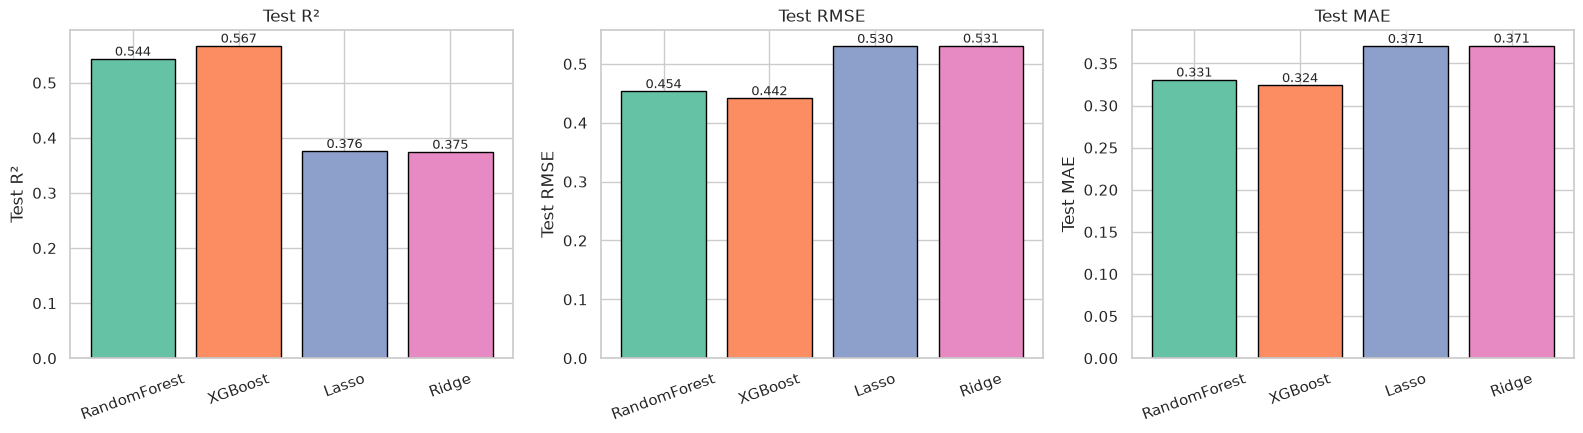

In [13]:
names = list(results.keys())
metrics = {
    "Test R²": [results[n]["test_r2"] for n in names],
    "Test RMSE": [results[n]["test_rmse"] for n in names],
    "Test MAE": [results[n]["test_mae"] for n in names],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
palette = sns.color_palette("Set2", n_colors=len(names))
for ax, (mname, vals) in zip(axes, metrics.items()):
    bars = ax.bar(names, vals, color=palette, edgecolor="black")
    ax.set_title(mname)
    ax.set_ylabel(mname)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

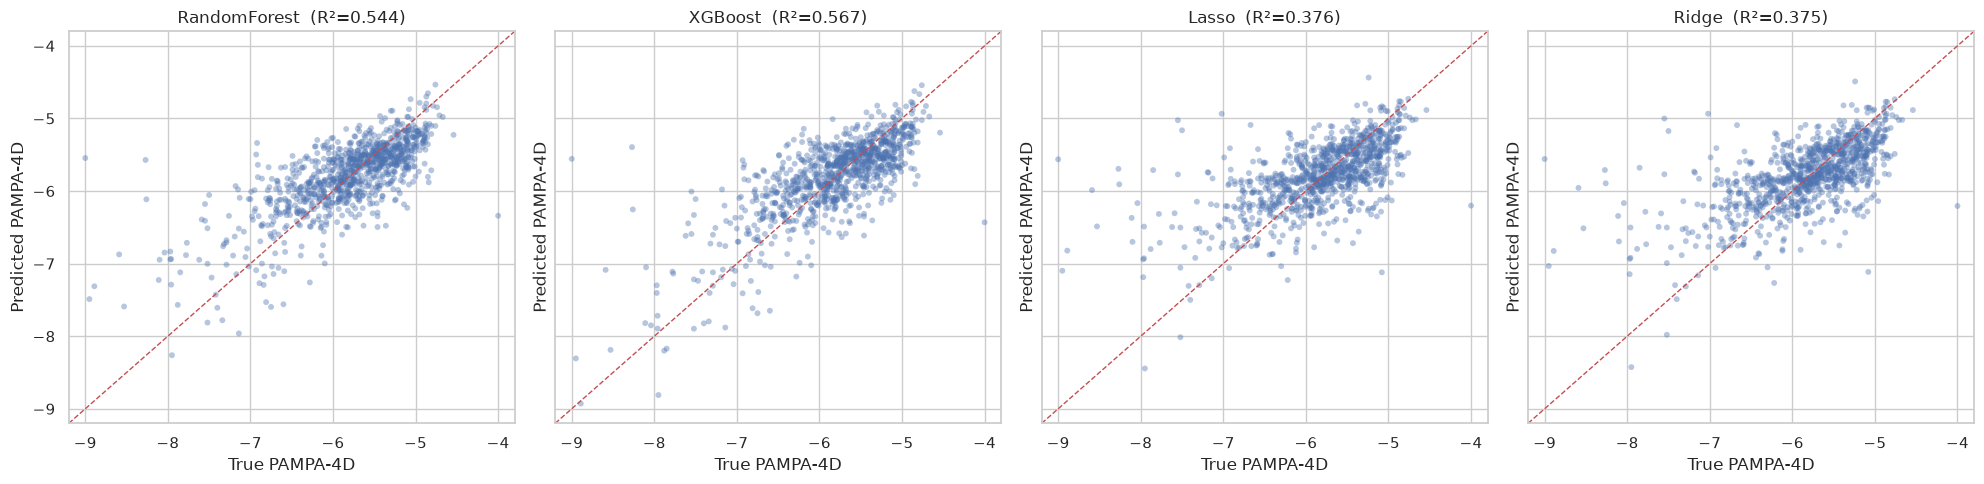

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
lo, hi = y_test.min() - 0.2, y_test.max() + 0.2
for ax, name in zip(axes, names):
    yp = results[name]["y_pred"]
    ax.scatter(y_test, yp, alpha=0.4, s=18, edgecolor="none")
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_title(f"{name}  (R²={results[name]['test_r2']:.3f})")
    ax.set_xlabel("True PAMPA-4D")
    ax.set_ylabel("Predicted PAMPA-4D")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
plt.tight_layout()
plt.show()

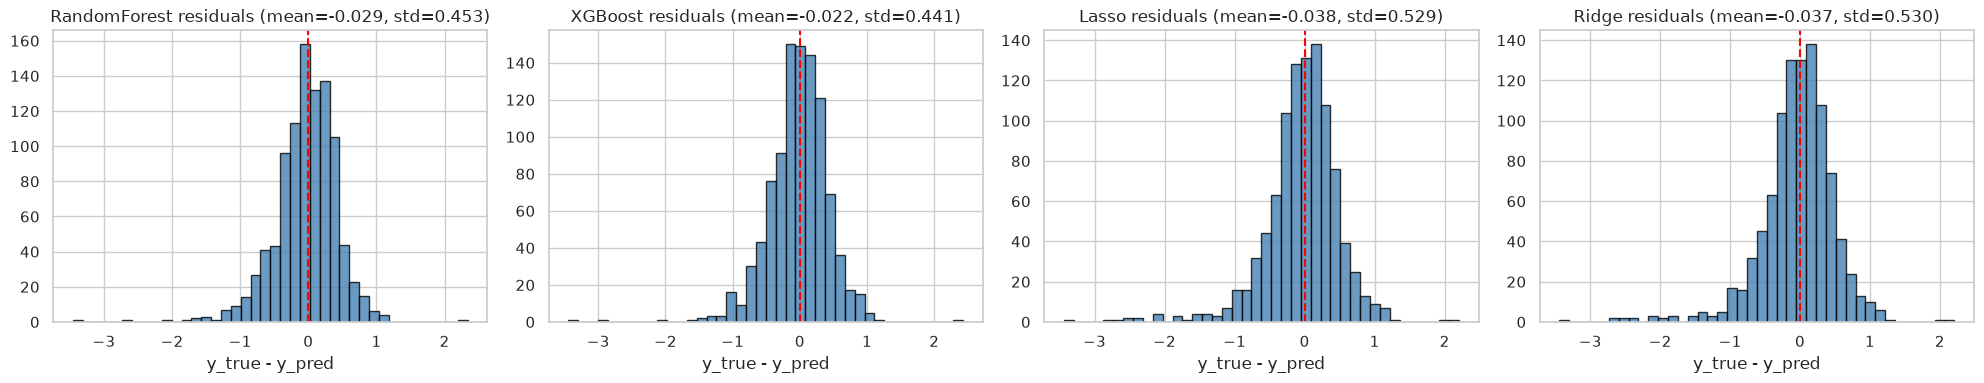

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, name in zip(axes, names):
    res_arr = y_test.values - results[name]["y_pred"]
    ax.hist(res_arr, bins=40, color="steelblue", edgecolor="black", alpha=0.8)
    ax.axvline(0, color="red", ls="--")
    ax.set_title(f"{name} residuals (mean={res_arr.mean():.3f}, std={res_arr.std():.3f})")
    ax.set_xlabel("y_true - y_pred")
plt.tight_layout()
plt.show()

## 7. 특성 중요도 / 계수 통합 비교

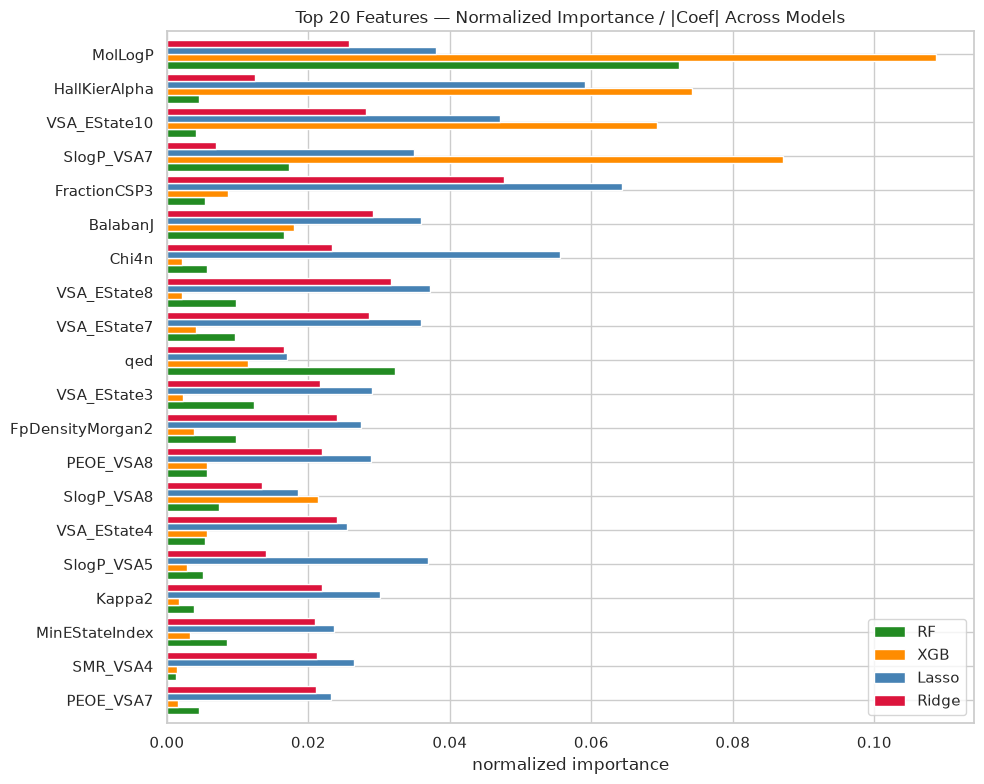


Top 20 (by mean across models):


,RF,XGB,Lasso,Ridge,mean
MolLogP,0.0724,0.1087,0.0380,0.0257,0.0612
HallKierAlpha,0.0046,0.0742,0.0591,0.0124,0.0376
VSA_EState10,0.0041,0.0692,0.0471,0.0282,0.0372
SlogP_VSA7,0.0172,0.0871,0.0350,0.0069,0.0365
FractionCSP3,0.0054,0.0086,0.0643,0.0476,0.0315
BalabanJ,0.0166,0.0180,0.0359,0.0291,0.0249
Chi4n,0.0057,0.0021,0.0556,0.0233,0.0217
VSA_EState8,0.0097,0.0022,0.0371,0.0317,0.0202
VSA_EState7,0.0097,0.0040,0.0360,0.0285,0.0195
qed,0.0322,0.0114,0.0170,0.0166,0.0193


In [16]:
def normalize(s):
    s = s.abs()
    return s / s.sum() if s.sum() > 0 else s

imp_df = pd.DataFrame({
    "RF": normalize(rf_imp),
    "XGB": normalize(xgb_imp),
    "Lasso": normalize(lasso_coef),
    "Ridge": normalize(ridge_coef),
}).fillna(0)

imp_df["mean"] = imp_df.mean(axis=1)
top_overall = imp_df.sort_values("mean", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_overall.drop(columns="mean").iloc[::-1].plot.barh(
    ax=ax, stacked=False, width=0.85,
    color=["forestgreen", "darkorange", "steelblue", "crimson"],
)
ax.set_title("Top 20 Features — Normalized Importance / |Coef| Across Models")
ax.set_xlabel("normalized importance")
plt.tight_layout()
plt.show()

print("\nTop 20 (by mean across models):")
top_overall.round(4)

## 8. 요약

- **Random Forest / XGBoost**: 비선형 상호작용을 잡아 일반적으로 R² 가 더 높음. XGBoost 가 보통 더 미세하게 조정 가능.
- **Lasso (L1)**: 자동 특성 선택. 비제로 계수 수가 의미있는 특성의 sparsity를 보여줌.
- **Ridge (L2)**: 계수 축소(non-zero 유지). 상관 높은 descriptor 다수 환경에서 안정적.
- **공통 상위 특성**: 4 모델 모두에서 상위에 등장하는 특성은 PAMPA-4D 예측에 robust한 신호를 갖는 후보.